In [1]:
from functions import extract_surface_lines_np
import numpy as np
import tensorflow as tf

2025-11-17 11:08:10.744714: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 11:08:10.776294: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-17 11:08:11.381422: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# test function
with open('models/cone/a cone with a 10.00mm diameter and a 20.00mm height.brep', 'r', encoding='utf-8') as f:
    b = f.read()
    print(extract_surface_lines_np(b))

[ 0.          0.         20.          0.          0.         -1.
 -1.          0.         -0.          0.          1.          0.
  0.          0.24497867  0.          0.          0.          0.
  0.         -1.         -1.          0.         -0.          0.
  1.          0.        ]


In [3]:
import os

shapes = ['0', '1', '2', '3', '4', '5']

file_list = [os.listdir('Traceparts_brep/' + shape) for shape in shapes]

X = []
y = []

for shape in shapes:
    y.append([shape]*len(os.listdir('Traceparts_brep/' + shape)))

# flatten
file_list = [item for items in file_list for item in items]
y = [item for items in y for item in items]

for i in range(0, len(file_list)):
    with open('Traceparts_brep/' + y[i] + '/' + file_list[i], 'r', encoding='utf-8') as f:
        brep_str = f.read()
        X.append(extract_surface_lines_np(brep_str))

In [4]:
from numpy import float32
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

maxlen = 1024
X_pad = pad_sequences(X, maxlen=maxlen, dtype='float32', padding='post', truncating='post', value=0.0)
X_pad = X_pad[..., None]

num_outputs = len(shapes)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_arr = np.asarray(y_encoded, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(X_pad, y_arr, test_size=0.2, random_state=3)

model = models.Sequential([
    layers.Input(shape=(maxlen, 1)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_outputs, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

W0000 00:00:1763395692.403472 2359159 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
model_trained = model.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=64)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6690 - loss: 4.3572 - val_accuracy: 0.8750 - val_loss: 0.3236
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9352 - loss: 0.2743 - val_accuracy: 0.9375 - val_loss: 0.2127
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9769 - loss: 0.0905 - val_accuracy: 0.9583 - val_loss: 0.1699
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9884 - loss: 0.0495 - val_accuracy: 0.9583 - val_loss: 0.1540
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0304 - val_accuracy: 0.9583 - val_loss: 0.1462
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9954 - loss: 0.0257 - val_accuracy: 0.9792 - val_loss: 0.1414
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9954 - loss: 0.0220 - val_accuracy: 0.9792 - val_loss: 0.1383
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9954 - loss: 0.0196 - val_accuracy: 0.9792 - val_loss: 0.1356
Epoch 9

In [6]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

In [8]:
#prediction
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [9]:
#accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


In [10]:
#Precision/Recall/F1

print(classification_report(y_test, y_pred_classes, target_names=shapes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.92      0.96      0.94        25
           2       0.80      0.57      0.67        14
           3       0.96      1.00      0.98        23
           4       1.00      1.00      1.00        16
           5       0.88      0.95      0.91        22

    accuracy                           0.93       120
   macro avg       0.93      0.91      0.92       120
weighted avg       0.93      0.93      0.93       120



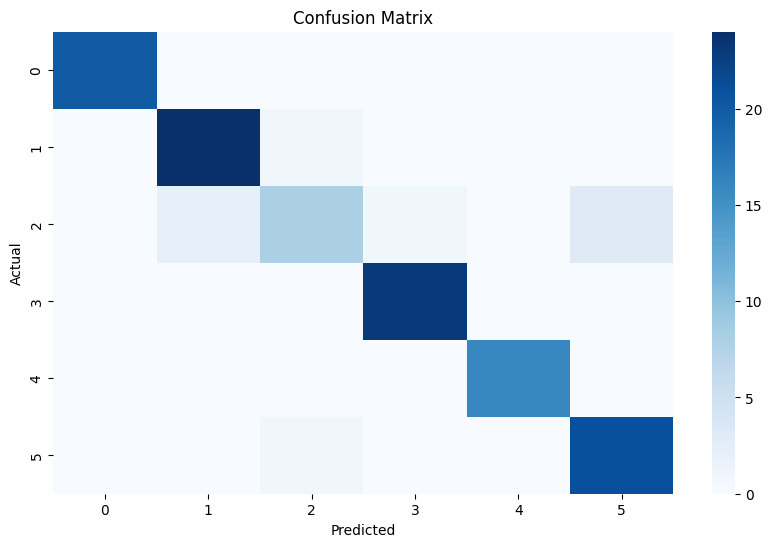

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_mat = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,6))
sns.heatmap(conf_mat, annot=False, cmap='Blues', fmt='d',
            xticklabels=shapes, yticklabels=shapes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()